In [1]:
import os
import sys

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
# 1. common과 data 폴더가 있는 프로젝트 루트 디렉터리를 찾아 작업 경로(os.chdir) 및 sys.path 설정
curr = os.path.abspath('')
while curr != os.path.dirname(curr):
  if os.path.exists(os.path.join(curr, 'common')) and os.path.exists(
      os.path.join(curr, 'data')
  ):
    os.chdir(curr)  # 작업 디렉터리를 프로젝트 루트로 변경
    if curr not in sys.path:
      sys.path.insert(0, curr)
    break
  curr = os.path.dirname(curr)

In [5]:
import common.loader as loader
import common.viz as viz

In [6]:
# 3. 시각화 환경 설정 (한글 폰트 및 마이너스 깨짐 방지)
viz.setup()

In [7]:
# 4. 데이터 로드
master = loader.load_master('data/master.csv')
scores = pd.read_csv(
    'data/scores.csv', encoding='utf-8-sig', dtype=loader.KEY_DTYPES
)

## 업종별 폐업률 분포

- 핵심: 전자상거래업, 커피-음료, 분식전문점 등 진입 장벽이 낮고 유행 변화가 빠른 업종일수록 평균 폐업률이 상대적으로 높게 형성되어 있습니다.

즉, 인터넷 쇼핑몰, 카페, 분식집처럼 누구나 쉽게 창업할 수 있고 경쟁이 치열한 업종일수록 가게가 문을 닫는 비율이 높습니다.

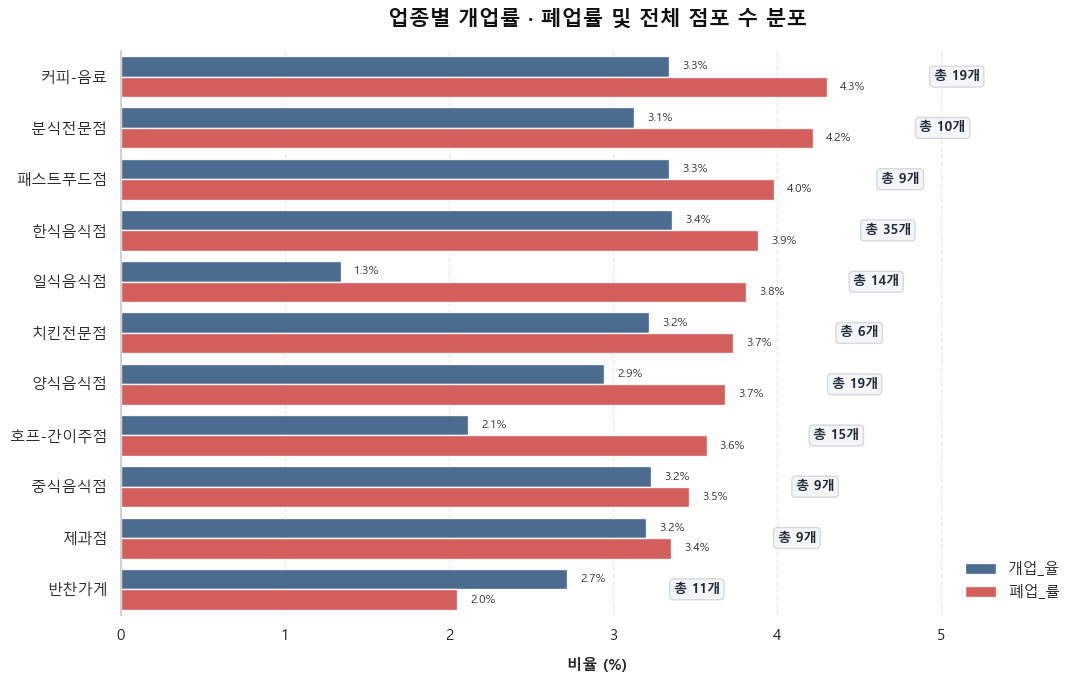

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 화이트리스트 필터링 및 집계
whitelist_df = pd.read_csv('config/업종_whitelist.csv')
whitelist_industries = whitelist_df.iloc[:, 0].unique()

filtered_master = master[
    master['서비스_업종_코드_명'].isin(whitelist_industries)
]

# 개업률, 폐업률, 전체 점포 수 집계
industry_summary = (
    filtered_master.groupby('서비스_업종_코드_명')[
        ['개업_율', '폐업_률', '전체_점포_수']
    ]
    .mean()
    .sort_values(by='폐업_률', ascending=False)
    .reset_index()
)

# 개업률 vs 폐업률 비교를 위한 melt 변환
rates_df = industry_summary.melt(
    id_vars=['서비스_업종_코드_명', '전체_점포_수'],
    value_vars=['개업_율', '폐업_률'],
    var_name='구분',
    value_name='비율',
)

# 2. 스타일 및 테마 설정 (임의의 sns.set_theme 호출 제거 완료: viz.setup() 환경 상속)
fig, ax = plt.subplots(figsize=(11, 7))

# 3. 가로 막대그래프 생성 (개업률: 파란색 / 폐업률: 붉은색)
bars = sns.barplot(
    data=rates_df,
    x='비율',
    y='서비스_업종_코드_명',
    hue='구분',
    palette=['#2B5C8F', '#E53935'],
    ax=ax,
    alpha=0.9,
)

# 4. 막대 우측 비율(%) 수치 텍스트 표시
for p in ax.patches:
    val = p.get_width()
    if val > 0:
        ax.annotate(
            f'{val:.1f}%',
            (val + 0.08, p.get_y() + p.get_height() / 2.0),
            ha='left',
            va='center',
            fontsize=8.5,
            color='#333333',
        )

# 5. 막대 우측 끝에 전체 점포 수 카운트 박스 표시
for i, row in industry_summary.iterrows():
    max_rate = max(row['개업_율'], row['폐업_률'])
    ax.annotate(
        f"총 {int(row['전체_점포_수']):,}개",
        (max_rate + 0.65, i),
        ha='left',
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color='#1F2937',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#F3F4F6',
            edgecolor='#D1D5DB',
            alpha=0.9,
        ),
    )

# 6. 디자인 디테일 다듬기
ax.set_title(
    '업종별 개업률 · 폐업률 및 전체 점포 수 분포',
    fontsize=15,
    fontweight='bold',
    pad=18,
    color='#111111',
)
ax.set_xlabel('비율 (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('')  # Y축 라벨 제거로 가독성 향상
ax.set_xlim(0, rates_df['비율'].max() * 1.35)  # 우측 여백 확보 (카운트 박스 잘림 방지)
ax.legend(title='', frameon=True, facecolor='white', edgecolor='none')

# 불필요한 테두리 정리
sns.despine(top=True, right=True, left=False, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.yaxis.grid(False)

plt.tight_layout()

# 7. 저장 및 출력
viz.save(fig, '01c_업종별_폐업률_분포')
plt.show()

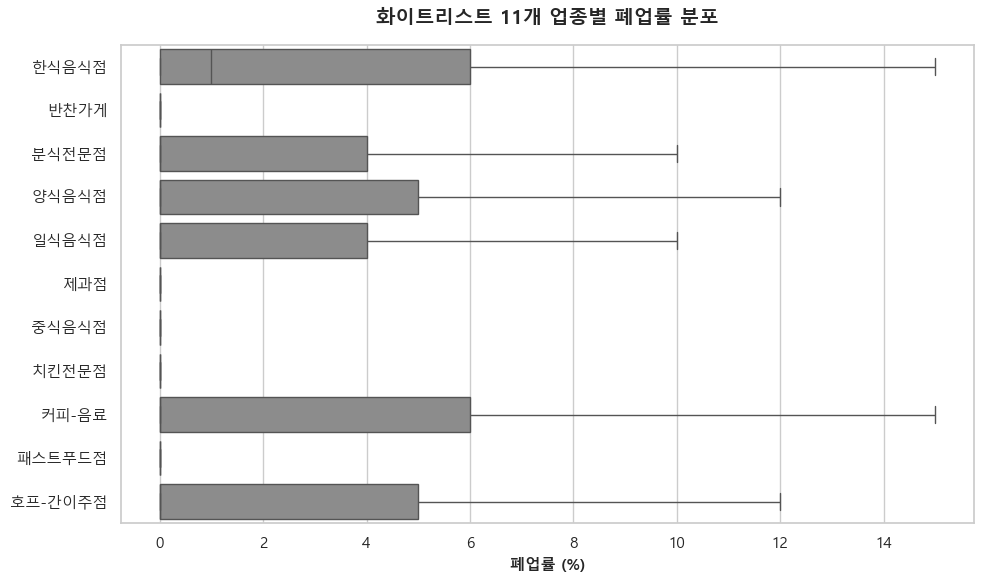

In [9]:
# [그래프 01] 화이트리스트 11개 업종별 폐업률 분포 (Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns

# 화이트리스트 업종 필터링 및 폐업률 중앙값 순 정렬
filtered_master = master[master['서비스_업종_코드_명'].isin(whitelist_industries)]
order_11 = filtered_master.groupby('서비스_업종_코드_명')['폐업_률'].median().sort_values(ascending=False).index

# 팔레트 설정 (함수 호출 결과인 리스트를 전달)
palette_colors = viz.palette(order_11) if callable(getattr(viz, 'palette', None)) else 'Set2'

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=filtered_master,
    y='서비스_업종_코드_명',
    x='폐업_률',
    order=order_11,
    hue='서비스_업종_코드_명',  # Seaborn 최신 버전 경고 방지 및 팔레트 매핑
    palette=palette_colors,
    legend=False,
    showfliers=False,
    ax=ax
)

ax.set_title('화이트리스트 11개 업종별 폐업률 분포', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('폐업률 (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
viz.save(fig, '01_업종별_폐업률_분포')
plt.show()

### 대조군

C:\Users\chans\AppData\Local\Temp\ipykernel_30676\16105070.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


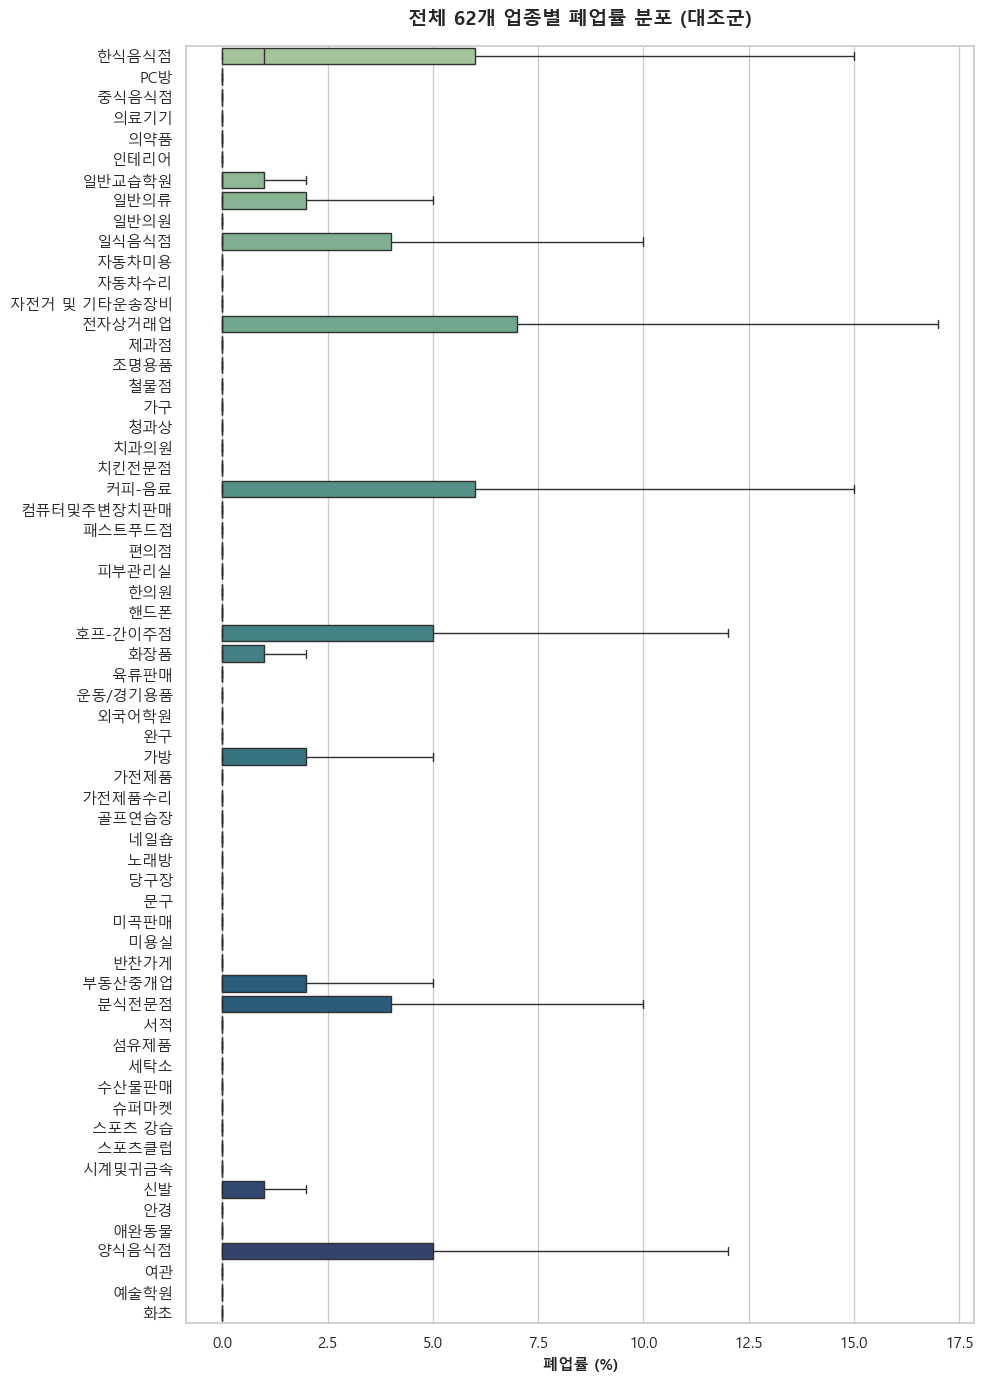

In [10]:
# [그래프 01b] 전체 62개 업종별 폐업률 분포 (대조군 Boxplot)
# 대조군: 전 업종 의도적 사용
order_62 = master.groupby('서비스_업종_코드_명')['폐업_률'].median().sort_values(ascending=False).index

# 62개 업종 가독성을 위해 세로 길이를 14로 확대
fig, ax = plt.subplots(figsize=(10, 14))
sns.boxplot(
    data=master,
    y='서비스_업종_코드_명',
    x='폐업_률',
    order=order_62,
    palette='crest',
    showfliers=False,
    ax=ax
)

ax.set_title('전체 62개 업종별 폐업률 분포 (대조군)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('폐업률 (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
viz.save(fig, '01b_업종별_폐업률_분포_62종대조')
plt.show()

## 상권 구분별 공급 밀도 

**관광특구**- 평균 공급밀도 : 52.77 중앙값 : 30.09
압도적 점포 밀집: 유효수요 대비 점포 공급이 다른 상권에 비해 현저히 높으며, 상권 간 편차(분포 범위)도 가장 큽니다.
[주의: 관광특구 경우 우상향 꼬리가 길다.]
- 그 이유, 
명동, 명동 관광 특구, 이태원 등 일부 초고밀도 관광특구 상권이 수치를 엄청나게 끌어올리고 있음을 뜻한다. 박스의 75% 선 Q3 위쪽 공간이 박스 아래쪽보다 훨씬 길게 늘어진 것이 바로 이 때문이다.

**발달상권**- 평균 공급밀도 : 17.10 중앙값 : 10.90
중상위 수준의 경쟁: 도심 및 대형 상업지구 특성상 점포 밀집도가 높고, 우상향 꼬리가 길어 평균이 중앙값보다 높게 형성됩니다.
[주의: 발달상권 경우 우상향 꼬리가 길다. 단, 상대적으로 짧지만 명확한 우상향 고리]
- 그 이유, 
일반적인 발달 상권은 10 내외 수준이지만, 강남/홍대 등 핵심 발달상권 일부가 길게 꼬리를 형성하고 있다. 

**전통시장**- 평균 10.29 중앙값 : 8.04
보통 수준의 밀집도: 상권 형태가 규격화되어 있어 분포 상하한 폭이 좁고 안정적인 편차를 보입니다.

**골목상권**- 평균 7.79 중앙값 : 6.29 
가장 낮은 공급 밀도: 주거지 기반 상권으로 점포가 분산되어 있어 유효수요 대비 과당경쟁 위험이 상대적으로 적습니다.


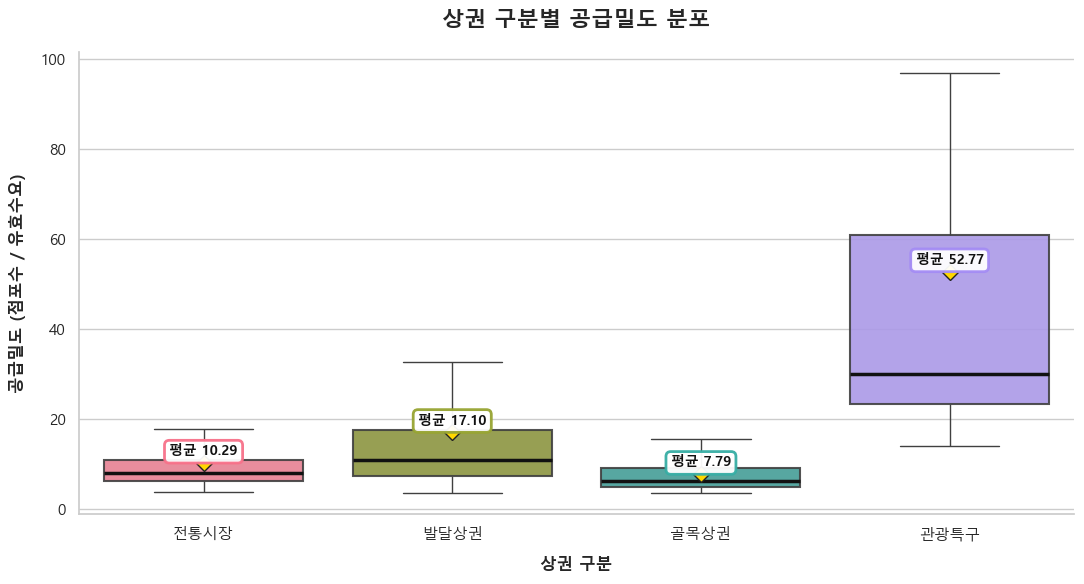

In [12]:
# [그래프 02] 상권 구분별 공급밀도 분포 (A안: scores 공급밀도 기준)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 6))

# 1. 상권 구분 카테고리 및 팔레트 설정 (scores 데이터셋 참조)
categories = scores['상권_구분_코드_명'].dropna().unique()
vibrant_palette = sns.color_palette('husl', n_colors=len(categories))

# 2. 박스플롯 작성 (scores의 공급밀도 지표 직접 사용)
sns.boxplot(
    data=scores,
    x='상권_구분_코드_명',
    y='공급밀도',
    hue='상권_구분_코드_명',
    palette=vibrant_palette,
    showfliers=False,  # 이상치 제외
    showmeans=True,  # 평균값 표시
    meanprops={
        'marker': 'D',
        'markerfacecolor': '#FFD700',
        'markeredgecolor': '#222222',
        'markersize': 8,
    },
    boxprops={'alpha': 0.9, 'linewidth': 1.5},
    medianprops={'color': '#111111', 'linewidth': 2.5},
    ax=ax,
)

# seaborn 최신 버전에 따른 범례 처리
if ax.legend_:
    ax.legend_.remove()

# 3. 평균값 수치 태그 작성
means = scores.groupby('상권_구분_코드_명')['공급밀도'].mean()

for i, category in enumerate(categories):
    mean_val = means[category]
    box_color = vibrant_palette[i]

    ax.text(
        i,
        mean_val + (means.max() * 0.02),
        f'평균 {mean_val:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#111111',
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='white',
            edgecolor=box_color,
            linewidth=2.0,
            alpha=0.95,
        ),
    )

# 4. 축 및 타이틀 변경 (이름 충돌 방지)
ax.set_title('상권 구분별 공급밀도 분포', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('상권 구분', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel(
    '공급밀도 (점포수 / 유효수요)',
    fontsize=12,
    fontweight='bold',
    labelpad=10,
)

sns.despine(top=True, right=True)
plt.tight_layout()

viz.save(fig, '02_상권구분별_공급밀도_분포')
plt.show()

## 유입강도 x 가구당인구 산점도
- 핵심 요약형 (발표 발표용)
"유입강도 상위 25% 선(붉은 점선)을 기준으로 **가족 주거형(초록색, 100%)**과 일반 주거·생활형(회색) 상권은 모두 선 왼쪽에만 배치되어 명확한 경계를 보여줍니다. 반면 유입 집중형(주황색), 발달상권형(보라색), **전통시장형(갈색)**은 선 오른쪽에 45~56% 이상 분포하여, 주거 기반 상권과 유입 기반 상권을 분류하는 핵심 축으로서의 타당성을 입증합니다."

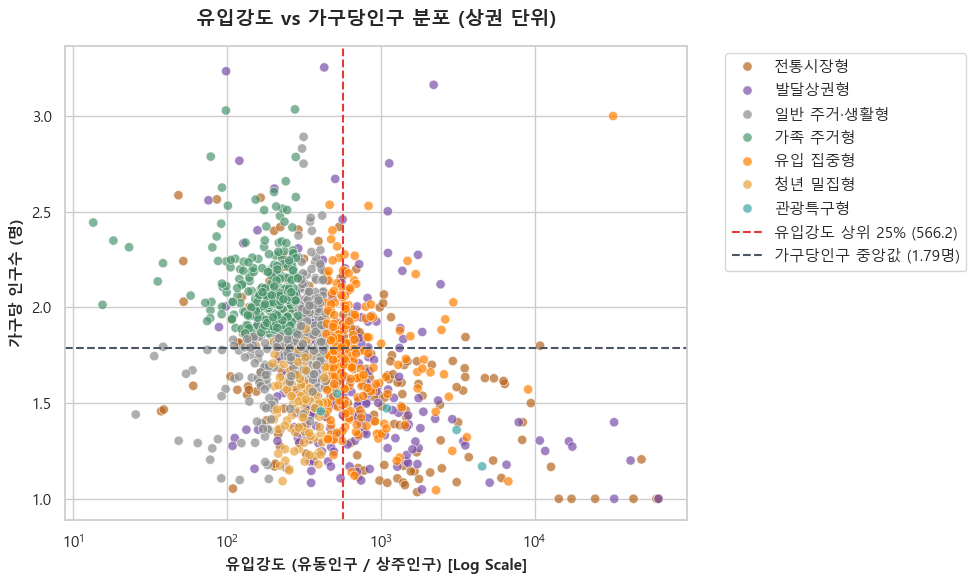

In [13]:
# [그래프 03] 유입강도 vs 가구당인구 산점도 (상권 단위 및 유형별 분포)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파생변수 생성
master['유입강도'] = loader.safe_ratio(master['총_유동인구_수'], master['총_상주인구_수'])
master['가구당인구'] = loader.safe_ratio(master['총_상주인구_수'], master['총_가구_수'])

# 2. 중복 플롯 제거: 20261 분기 기준 상권당 1개 대표행 추출 (10만여 개 중복 점 제거)
master_20261 = master[master['기준_년분기_코드'].astype(str) == '20261'].drop_duplicates('상권_코드')

# 3. 색상 축 교정: scores 테이블에서 상권_코드 기준 유형(7종) 조인
sangkwon_type = scores[['상권_코드', '유형']].drop_duplicates('상권_코드')
master_scatter = pd.merge(master_20261, sangkwon_type, on='상권_코드', how='inner')

# 4. 안전한 팔레트 딕셔너리 구성 (viz.TYPE_COLORS KeyMissing 방지)
unique_types = master_scatter['유형'].unique()
if hasattr(viz, 'TYPE_COLORS') and isinstance(viz.TYPE_COLORS, dict):
    default_colors = sns.color_palette('Set1', len(unique_types))
    palette_dict = {
        t: viz.TYPE_COLORS.get(t, default_colors[i])
        for i, t in enumerate(unique_types)
    }
else:
    palette_dict = 'Set1'

# 5. 분류 축 타당성 검증을 위한 사분위 임계선 산출
x_q75 = master_scatter['유입강도'].quantile(0.75)
y_med = master_scatter['가구당인구'].median()

# 6. 시각화
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=master_scatter,
    x='유입강도',
    y='가구당인구',
    hue='유형',
    palette=palette_dict,
    alpha=0.7,
    s=45,
    ax=ax,
)

# 축 타당성 검증 사분위 임계선 표기 (axvline / axhline)
ax.axvline(
    x=x_q75,
    color='#E53935',
    linestyle='--',
    linewidth=1.5,
    label=f'유입강도 상위 25% ({x_q75:.1f})',
)
ax.axhline(
    y=y_med,
    color='#4B5563',
    linestyle='--',
    linewidth=1.5,
    label=f'가구당인구 중앙값 ({y_med:.2f}명)',
)

ax.set_xscale('log')
ax.set_title('유입강도 vs 가구당인구 분포 (상권 단위)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('유입강도 (유동인구 / 상주인구) [Log Scale]', fontsize=11, fontweight='bold')
ax.set_ylabel('가구당 인구수 (명)', fontsize=11, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
viz.save(fig, '03_유입강도_가구당인구_산점도')
plt.show()

## 유형별 요일 매출 패턴

- 핵심: 주중 상권형은 금요일 매출 비중이 18.3%로 최고치를 기록하는 반면, 관광특구형은 토요일 비중이 18.8%까지 상승하며 요일별 비중 분포에서 명확한 차이를 입증한다.

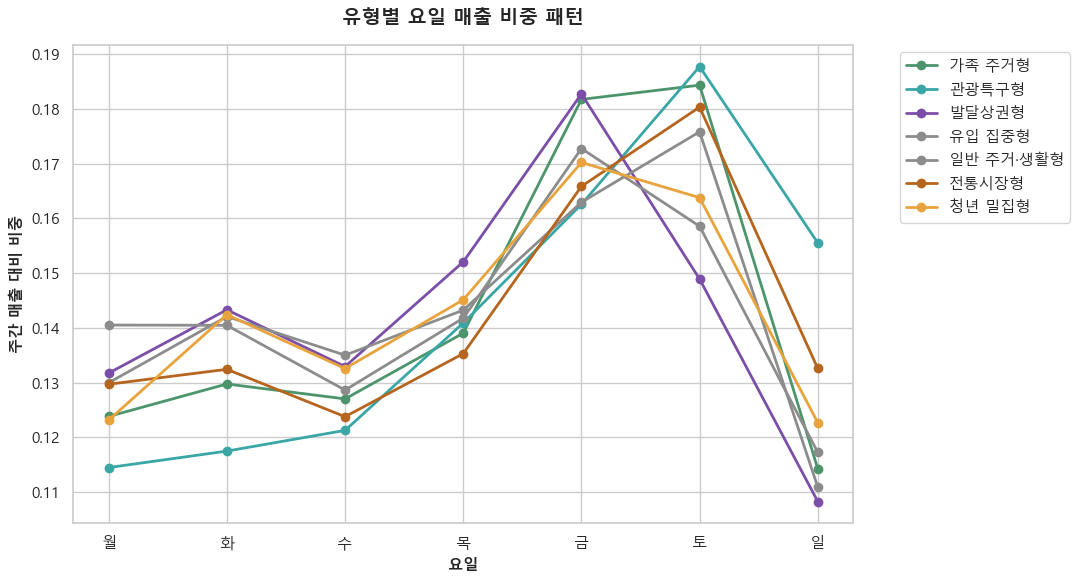

In [55]:
dow_cols = [
    '월요일_매출_금액',
    '화요일_매출_금액',
    '수요일_매출_금액',
    '목요일_매출_금액',
    '금요일_매출_금액',
    '토요일_매출_금액',
    '일요일_매출_금액',
]
dow_names = ['월', '화', '수', '목', '금', '토', '일']

# 1. 2026년 1분기 필터링 (분기 혼입 버그 방지)
# data 타입(int/str)에 상관없이 20261 분기만 정확히 추출
master_20261 = master[master['기준_년분기_코드'].astype(str) == '20261']

# 2. 조인 수행 (20261 필터 후 (상권, 업종)이 유일하므로 drop_duplicates 불필요)
merged_df = pd.merge(
    scores[['상권_코드', '서비스_업종_코드', '유형']],
    master_20261[['상권_코드', '서비스_업종_코드'] + dow_cols],
    on=['상권_코드', '서비스_업종_코드'],
    how='inner',
)

# 3. 검산: merged_df 행 수와 scores 행 수(3,443) 일치 여부 확인
assert len(merged_df) == len(scores), f"행 수 불일치 버그: merged={len(merged_df)}, scores={len(scores)}"

# 4. 유형별 평균 계산 후 주간 합 대비 비율로 정규화 (유형별 7일 합 = 1)
type_dow_mean = merged_df.groupby('유형')[dow_cols].mean()
type_dow_ratio = type_dow_mean.div(type_dow_mean.sum(axis=1), axis=0)
type_dow_ratio.columns = dow_names

# 5. 시각화 (viz.setup() 환경 유지, sns.set_theme 재호출 없음)
fig, ax = plt.subplots(figsize=(11, 6))
for u_type, row in type_dow_ratio.iterrows():
    color = viz.TYPE_COLORS.get(u_type, '#8C8C8C')
    ax.plot(
        dow_names,
        row.values,
        marker='o',
        label=u_type,
        color=color,
        linewidth=2,
    )

ax.set_title('유형별 요일 매출 비중 패턴', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('요일', fontsize=11, fontweight='bold')
ax.set_ylabel('주간 매출 대비 비중', fontsize=11, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

viz.save(fig, '04_유형별_요일_매출패턴')
plt.show()

## 유형별 공급갭 분포

**공급갭 = (동일 유형×업종 중앙 공급밀도 − 해당 상권 공급밀도) ÷ 동일 유형×업종 중앙 공급밀도** (DEV_SPEC §5-4)

같은 유형·같은 업종의 다른 상권과 비교했을 때 이 상권에 점포가 **얼마나 덜 들어와 있는가**를 비율로 잰 값이다. 서울 전체를 한 줄로 세우면 "번화가가 좋다"는 자명한 결론으로 수렴하므로, 비교군(유형)을 먼저 정의한 뒤 그 안에서 갭을 탐지한다.

### 부호 방향 — 값이 클수록 점포가 '적다'

| 구분 | 의미 | 실측 (공급갭 상·하위 200행) |
|---|---|---|
| **공급갭 큼** | 같은 유형 대비 점포가 **적다** → 진입 여지가 크다 → **좋은 후보** | 평균 공급밀도 7.38 · 평균 점포수 4.6개 |
| **공급갭 작음** | 같은 유형 대비 점포가 **많다** → 이미 채워져 있다 | 평균 공급밀도 15.80 · 평균 점포수 11.0개 |

- 공급밀도와 공급갭의 상관은 **−0.174**로 음의 관계다.
- `갭점수 = minmax(공급갭)`이 종합점수에 0.6 가중치로 그대로 들어간다 (`scripts/build_scores.py:100` · 공급갭↔갭점수 상관 1.000). **즉 이 대시보드는 공급갭이 높은 상권을 검토 후보로 제시한다.**
- `scores.csv`는 **공급갭 > 0인 행만** 담는다 (DEV_SPEC §5-4). 아래 박스플롯에 음수 구간이 없는 이유다.

### 중심값은 평균이 아니라 중앙값으로 읽는다

공급갭은 오른쪽 꼬리가 길어 평균이 꼬리에 끌려 올라간다. 실제로 **어느 유형이 가장 낮은지가 평균과 중앙값에서 서로 다르다.**

| | 최고 | 최저 |
|---|---|---|
| 평균 | 발달상권형 0.390 | 관광특구형 0.300 |
| **중앙값** | **발달상권형 0.387** | **일반 주거·생활형 0.290** |

유형 간 중심 비교가 목적이므로 아래 그래프는 **중앙값**을 태그로 표시한다.

**해석**: 발달상권형이 중앙값 0.387로 가장 높고 일반 주거·생활형이 0.290으로 가장 낮다 — 발달상권형에 "같은 발달상권인데 점포는 골목 수준으로만 들어와 있는" 상권이 다수 섞여 있다는 뜻이며(발달상권형 217개 중 89개, 41.0%가 골목상권 중앙 밀도 6.29 이하), 이것이 검토 후보 상위권을 발달상권형이 독점하는 원인이 된다.

> ⚠️ 아래 그래프는 `showfliers=False`로 **이상치를 제외**한다. 그런데 유형 편향을 만드는 것은 바로 그 오른쪽 꼬리다 (공급갭 0.8 초과 22행 중 14행이 발달상권형). 이 그림만으로는 편향의 크기가 보이지 않으므로 **그래프 07**에서 꼬리를 포함해 다시 본다.

C:\Users\chans\AppData\Local\Temp\ipykernel_30676\1252811483.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(types_in_scores, rotation=20, ha='right')


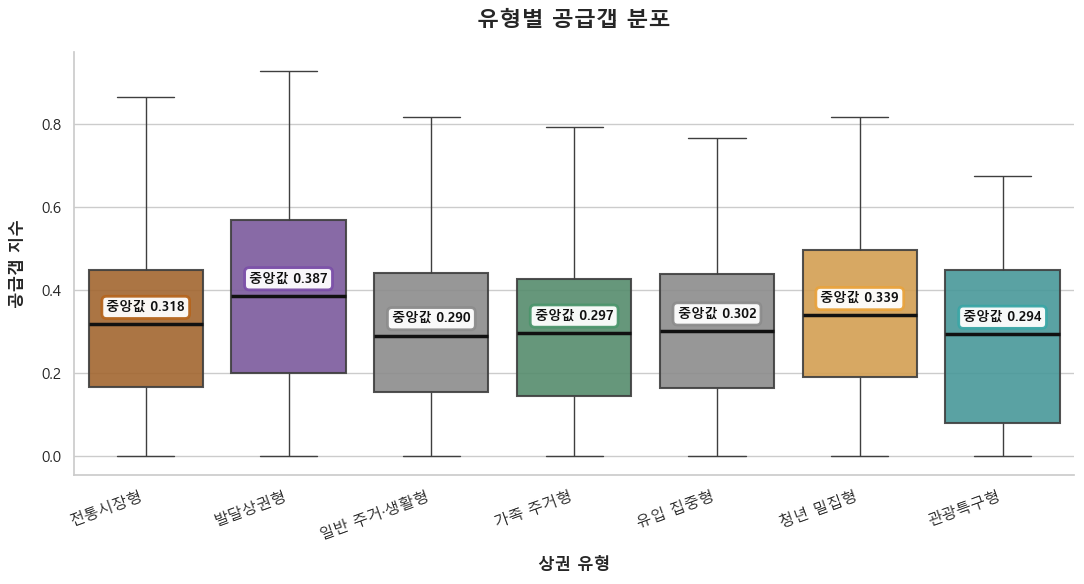

In [23]:
# [그래프 05] 유형별 공급갭 분포 (중앙값 태그)
import matplotlib.pyplot as plt
import seaborn as sns

types_in_scores = scores['유형'].dropna().unique().tolist()
custom_palette = (
    viz.palette(types_in_scores)
    if callable(getattr(viz, 'palette', None))
    else sns.color_palette('husl', n_colors=len(types_in_scores))
)

fig, ax = plt.subplots(figsize=(11, 6))

# 1. 박스플롯 생성
#    평균(showmeans) 대신 중앙값을 읽는다 — 공급갭은 오른쪽 꼬리가 길어(그래프 07 참조)
#    평균이 꼬리에 끌려 올라가고, 최저 유형이 평균과 중앙값에서 서로 달라진다.
sns.boxplot(
    data=scores,
    x='유형',
    y='공급갭',
    order=types_in_scores,
    hue='유형',
    palette=custom_palette,
    showfliers=True,  # 이상치 제외
    showmeans=False,   # 평균 마커 사용 안 함 (중앙값은 박스 내부 굵은 선)
    boxprops={'alpha': 0.9, 'linewidth': 1.5},
    medianprops={'color': '#111111', 'linewidth': 2.5},
    ax=ax,
)

if ax.legend_:
    ax.legend_.remove()

# 2. 중앙값 수치 말풍선 태그 추가
#    유형 간 중앙값이 0.290~0.387로 좁게 모여 있어 소수 3자리로 표기한다
medians = scores.groupby('유형')['공급갭'].median()

for i, category in enumerate(types_in_scores):
    med_val = medians[category]
    box_color = custom_palette[i]

    ax.text(
        i,
        med_val + 0.025,
        f'중앙값 {med_val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9.5,
        fontweight='bold',
        color='#111111',
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='white',
            edgecolor=box_color,  # 막대 색상과 동일한 테두리
            linewidth=2.0,
            alpha=0.95,
        ),
    )

# 3. 축 및 타이틀 레이아웃 설정
ax.set_title('유형별 공급갭 분포', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('상권 유형', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('공급갭 지수', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xticklabels(types_in_scores, rotation=20, ha='right')

sns.despine(top=True, right=True)
plt.tight_layout()

viz.save(fig, '05_유형별_공급갭_분포')
plt.show()

## 자치구별 후보수
- 핵심 : 강남구(약 285건)와 송파·중구 등 상권 유동인구가 풍부한 핵심 도심권이 후보지 수 상위권을 차지한 반면, 노원·도봉·금천 등 주거 중심 외곽 구역은 후보지 발굴 건수가 적은 편입니다.

최다 후보지 보유 구역 (200건 이상 ~ 150건 이상):
강남구 (약 285건): 서울 전체 자치구 중 독보적으로 가장 많은 후보지를 보유하고 있습니다.

상위권 그룹: 송파구(약 184건), 중구(약 170건), 영등포구(약 165건), 성북구(약 162건), 서초구(약 150건) 순으로 뒤를 잇습니다.

중위권 그룹 (120건 ~ 140건 대):
관악구, 은평구, 종로구, 마포구, 광진구, 강동구, 동작구, 양천구, 구로구, 강서구, 중랑구 등이 오차 범위 내에서 고르게 밀집되어 있습니다.

C:\Users\chans\AppData\Local\Temp\ipykernel_30676\238728984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chans\AppData\Local\Temp\ipykernel_30676\238728984.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(district_counts.index, rotation=45, ha='right')


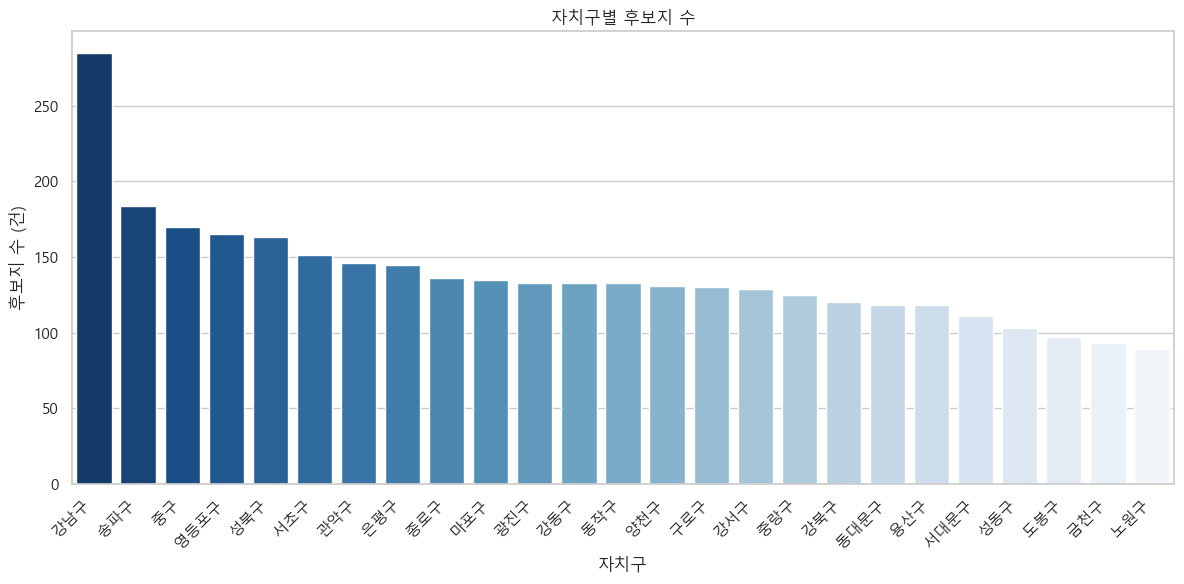

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
district_counts = scores['자치구_코드_명'].value_counts()

sns.barplot(
    x=district_counts.index, y=district_counts.values, palette='Blues_r', ax=ax
)
ax.set_xticklabels(district_counts.index, rotation=45, ha='right')
ax.set_title('자치구별 후보지 수')
ax.set_xlabel('자치구')
ax.set_ylabel('후보지 수 (건)')
plt.tight_layout()

viz.save(fig, '06_자치구별_후보수')
plt.show()

## 유형별 상위 후보 점유율과 정규화 스코프

그래프 05는 유형별 공급갭의 **중심**을 보여준다. 그런데 사용자가 화면에서 실제로 보는 것은 중심이 아니라 **상위 N개**다. "평균이 조금 높다"가 "상위를 독점한다"로 증폭되는지는 따로 확인해야 한다.

세 단계로 읽는다.

1. **편향의 크기** — 업종별 Top10 자리를 어느 유형이 가져가는가. 모수 비중과 나란히 놓아 과대표집 배수를 본다.
2. **편향의 원인** — 공급갭은 `1 − 공급밀도 ÷ 유형중앙값` 이므로, 유형 안에서 **아래로 내려갈 수 있는 폭**(공급밀도 최소 ÷ 유형 중앙값)이 곧 갭의 천장이 된다.
3. **원인의 증명** — 갭점수를 유형 **내부에서** min-max 하면 편향이 사라지는지 대조군으로 확인한다.

> **왜 이 확인이 필요한가**: DEV_SPEC §5-4는 *"서울 전체를 한 줄로 세우면 번화가가 좋다는 자명한 결론으로 수렴"* 하는 것을 막으려고 비교군(유형)을 도입했다. 그런데 §5-6의 `갭점수 = minmax(공급갭)`은 7개 유형을 **다시 한 줄로** 세운다. 갭은 유형 안에서 재고 점수는 유형 밖에서 매기는 **스코프 불일치**가 남아 있는지 보는 것이 이 그래프의 목적이다.

**해석**: 발달상권형은 후보 목록의 30.4%인데 업종별 Top10의 **93.6%**를 가져간다(과대표집 3.09배) — 원인은 발달상권형만 공급밀도 최소가 유형 중앙값의 **33.9%**로(다른 유형 47~63%) 갭의 천장이 0.93까지 열려 있기 때문이고, 갭점수를 유형 내부에서 정규화하면 상위 100건이 20/18/18/17/12/10/5로 고르게 흩어져 편향의 원인이 지표가 아니라 **정규화 스코프**임이 확인된다.

**관광특구형이 0칸인 이유**는 반대다 — 이질성이 **위로만** 있어 공급밀도 최소가 14.16(골목상권 중앙 6.29의 2.3배)이라 내려갈 여지가 없고, 그래서 최대 공급갭이 0.68에 그친다. 후보도 30행뿐이라 꼬리를 굴릴 기회 자체가 적다. **CV(변동계수)로는 관광특구형 0.888 · 발달상권형 1.013으로 비슷해 보이지만, CV는 양방향 산포를 합쳐 보기 때문에 이 차이를 잡아내지 못한다.**

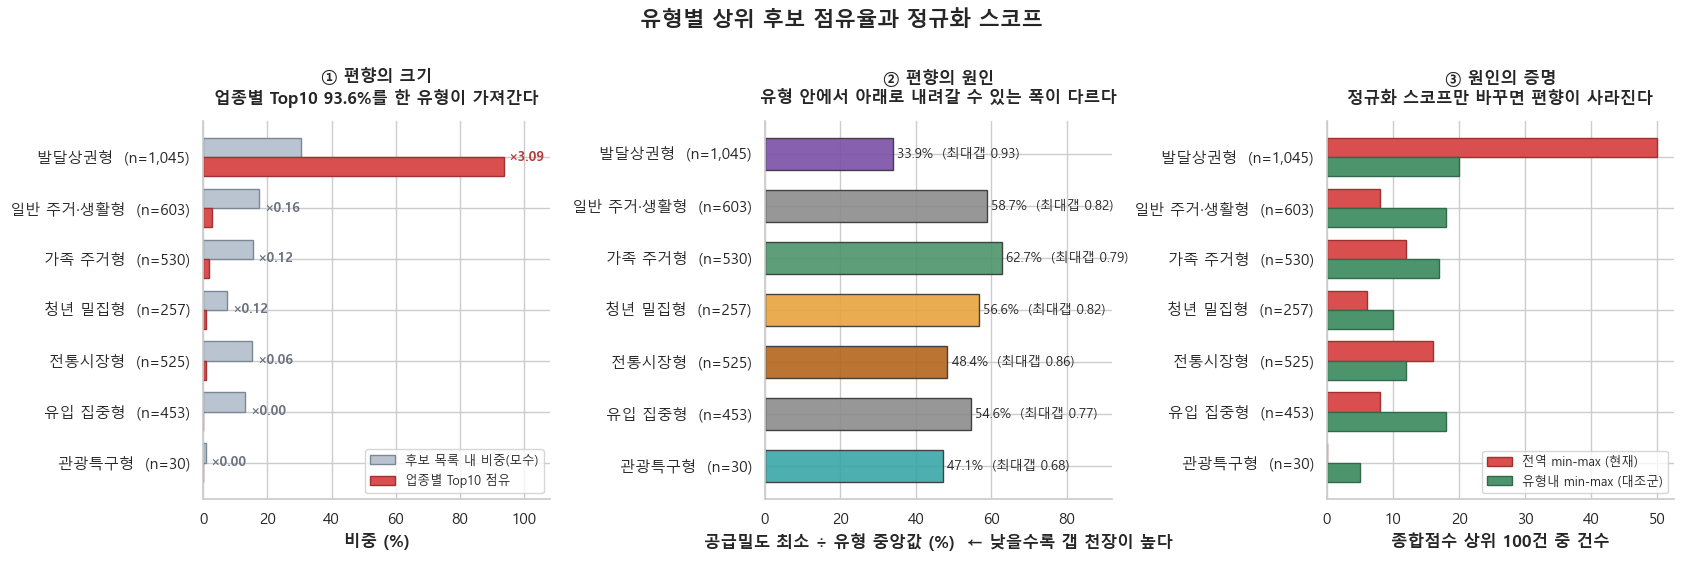

,모수%,Top10%,과대표집배수
유형,,,
관광특구형,0.87,0.00,0.00
유입 집중형,13.16,0.00,0.00
전통시장형,15.25,0.91,0.06
청년 밀집형,7.46,0.91,0.12
가족 주거형,15.39,1.82,0.12
일반 주거·생활형,17.51,2.73,0.16
발달상권형,30.35,93.64,3.09


,최소,중앙,최소÷중앙%,최대공급갭
유형,,,,
관광특구형,14.16,30.09,47.07,0.68
유입 집중형,3.63,6.66,54.59,0.77
전통시장형,3.89,8.04,48.37,0.86
청년 밀집형,3.76,6.64,56.64,0.82
가족 주거형,3.68,5.88,62.71,0.79
일반 주거·생활형,3.67,6.25,58.73,0.82
발달상권형,3.70,10.90,33.92,0.93


,전역 정규화 (현재),유형내 정규화 (대조군)
유형,,
관광특구형,0,5
유입 집중형,8,18
전통시장형,16,12
청년 밀집형,6,10
가족 주거형,12,17
일반 주거·생활형,8,18
발달상권형,50,20


In [21]:
# [그래프 07] 유형별 상위 후보 점유율과 정규화 스코프
# 그래프 05는 showfliers=False로 오른쪽 꼬리를 제외한다. 유형 편향을 만드는 것이
# 바로 그 꼬리이므로, 여기서는 꼬리를 포함해 '편향의 크기 → 원인 → 증명' 순으로 본다.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

W_GAP, W_STAB = 0.6, 0.4   # DEV_SPEC §5-6 확정 가중치
TOP_N = 10                 # 업종별 상위 N = 화면이 사용자에게 실제로 보여주는 범위

s = scores.copy()

# (1) 업종별 Top10을 누가 차지하는가 — 편향의 크기
thr = s.groupby('서비스_업종_코드_명')['종합점수'].nlargest(TOP_N).groupby(level=0).min()
s['_top'] = s['종합점수'] >= s['서비스_업종_코드_명'].map(thr)

share = pd.DataFrame({
    '모수%': s['유형'].value_counts(normalize=True) * 100,
    'Top10%': s.loc[s['_top'], '유형'].value_counts(normalize=True) * 100,
}).fillna(0)
share['과대표집배수'] = share['Top10%'] / share['모수%']
share = share.sort_values('Top10%')
order = share.index.tolist()

# (2) 하방 여유 — 유형 안에서 아래로 내려갈 수 있는 폭이 곧 공급갭의 천장이다
head = s.groupby('유형')['공급밀도'].agg(최소='min', 중앙='median')
head['최소÷중앙%'] = head['최소'] / head['중앙'] * 100
head['최대공급갭'] = s.groupby('유형')['공급갭'].max()
head = head.reindex(order)

# (3) 대조군 — 갭점수를 유형 내부에서 정규화하면 편향이 사라지는가
def _mm(x):
    return (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else x * 0 + 0.5

s['갭점수_유형내'] = s.groupby('유형')['공급갭'].transform(_mm)
s['종합_유형내'] = W_GAP * s['갭점수_유형내'] + W_STAB * s['안정성점수']
cmp_df = pd.DataFrame({
    '전역 정규화 (현재)': s.nlargest(100, '종합점수')['유형'].value_counts(),
    '유형내 정규화 (대조군)': s.nlargest(100, '종합_유형내')['유형'].value_counts(),
}).reindex(order).fillna(0)

# ── 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
y = range(len(order))
H = 0.38
# 후보 행 수를 축 라벨에 함께 적는다 — 관광특구형이 0칸인 이유(표본 30행)가 그림에서 읽혀야 한다
n_rows = s['유형'].value_counts().reindex(order)
labels = [f'{t}  (n={int(n):,})' for t, n in zip(order, n_rows)]

# 패널 ① 편향의 크기
ax = axes[0]
ax.barh([i + H / 2 for i in y], share['모수%'], H, label='후보 목록 내 비중(모수)',
        color='#B9C4D0', edgecolor='#7A8794')
ax.barh([i - H / 2 for i in y], share['Top10%'], H, label=f'업종별 Top{TOP_N} 점유',
        color='#D94F4F', edgecolor='#9E3232')
for i, (m, t, r) in enumerate(zip(share['모수%'], share['Top10%'], share['과대표집배수'])):
    ax.text(max(m, t) + 1.5, i, f'×{r:.2f}', va='center', fontsize=9.5, fontweight='bold',
            color='#B23B3B' if r > 1 else '#6B7280')
ax.set_yticks(list(y)); ax.set_yticklabels(labels)
ax.set_xlabel('비중 (%)', fontweight='bold')
ax.set_title(f'① 편향의 크기\n업종별 Top{TOP_N} {share["Top10%"].max():.1f}%를 한 유형이 가져간다',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='lower right'); ax.set_xlim(0, 108)

# 패널 ② 편향의 원인
ax = axes[1]
colors = [viz.TYPE_COLORS.get(t, '#8C8C8C') for t in order]
ax.barh(list(y), head['최소÷중앙%'], 0.62, color=colors, edgecolor='#333333', alpha=0.9)
for i, (v, g) in enumerate(zip(head['최소÷중앙%'], head['최대공급갭'])):
    ax.text(v + 1.2, i, f'{v:.1f}%  (최대갭 {g:.2f})', va='center', fontsize=9.5)
ax.set_yticks(list(y)); ax.set_yticklabels(labels)
ax.set_xlabel('공급밀도 최소 ÷ 유형 중앙값 (%)  ← 낮을수록 갭 천장이 높다', fontweight='bold')
ax.set_title('② 편향의 원인\n유형 안에서 아래로 내려갈 수 있는 폭이 다르다',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 92)

# 패널 ③ 원인의 증명
ax = axes[2]
ax.barh([i + H / 2 for i in y], cmp_df['전역 정규화 (현재)'], H,
        label='전역 min-max (현재)', color='#D94F4F', edgecolor='#9E3232')
ax.barh([i - H / 2 for i in y], cmp_df['유형내 정규화 (대조군)'], H,
        label='유형내 min-max (대조군)', color='#4C956C', edgecolor='#33684B')
ax.set_yticks(list(y)); ax.set_yticklabels(labels)
ax.set_xlabel('종합점수 상위 100건 중 건수', fontweight='bold')
ax.set_title('③ 원인의 증명\n정규화 스코프만 바꾸면 편향이 사라진다',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='lower right')

fig.suptitle('유형별 상위 후보 점유율과 정규화 스코프', fontsize=15.5, fontweight='bold', y=1.0)
sns.despine(fig=fig, top=True, right=True)
plt.tight_layout()

viz.save(fig, '07_유형별_상위점유율과_정규화스코프')
plt.show()

# 수치 표 — 발표 Q&A 대비용
display(share.round(2))
display(head.round(2))
display(cmp_df.astype(int))